In [23]:
import numpy as np
import pandas as pd
import itertools
import math

import scipy
from scipy.signal import hilbert, find_peaks, peak_prominences, butter, filtfilt
import statsmodels.api as sm

import matplotlib.pyplot as plt

from parselmouth.praat import call
from parselmouth import Sound 

## Goal

The goal of this notebook is to establish clear definitions and visualizations for the following vibrato measures:

- **Vibrato Rate (FM)**
- **Vibrato Extent (FM)**
- **Vibrato Rate (AM)**
- **Vibrato Extent (AM)**
- **Phase Difference (AM–FM)**

Synthetic signals are used to provide known ground truth values for all parameters.


In [302]:
import numpy as np

def generate_vibrato_signal(
    f0=100.0,
    fs=10000,
    T=4.0,
    VibRate_FM=6.0,
    VibExtent_cents=40.0,
    baseAmp=1,
    InstVibAmpRate=10.0,
    AM_depth=0.1,  # fraction 0 → 1
    fm_phase = 0,
    am_phase = 0
):
    """
    Vibrato signal with controllable AM depth.

    AM_depth = 1.0 → full modulation (0 → VibAmp)
    AM_depth = 0.3 → 30% modulation (0.7*VibAmp → VibAmp)
    """
    dt = 1.0 / fs
    t = np.arange(0, T + dt, dt)

    # Frequency modulation (linear Hz)
    cents_deviation = VibExtent_cents * np.sin(2.0 * np.pi * VibRate_FM * t + fm_phase)
    VibSignalFreq = f0 * (2.0 ** (cents_deviation / 1200.0))
    VibSignalPhase = 2.0 * np.pi * np.cumsum(VibSignalFreq) / fs

    # Amplitude envelope with controlled depth
    VibAmpInst = baseAmp * (1 + AM_depth * np.cos(2.0 * np.pi * InstVibAmpRate * t + am_phase))

    # Output
    VibratoSignal = VibAmpInst * np.sin(VibSignalPhase)

    return VibratoSignal, t


## Example Signal from Parameter Sweep

This section visualizes a representative synthetic vibrato signal with
simultaneous FM and AM, using parameters drawn from the sweep ranges.

In [336]:
# --- Characteristic sweep values ---
f0 = 294.0                 # Hz
fs = 10000                 # Hz
T = 2.0                    # seconds

vibRate_fm = 6.0           # Hz
vibExtent_cents = 40.0     # cents

vibRate_am = 6.0           # Hz
am_depth = 0.02            # 1% AM depth

fm_phase = 0.0
am_phase = 0#np.pi / 2

In [337]:
signal, t = generate_vibrato_signal(
    f0=f0,
    fs=fs,
    T=T,
    VibRate_FM=vibRate_fm,
    VibExtent_cents=vibExtent_cents,
    baseAmp=1.0,
    InstVibAmpRate=vibRate_am,
    AM_depth=am_depth,
    fm_phase=fm_phase,
    am_phase=am_phase
)

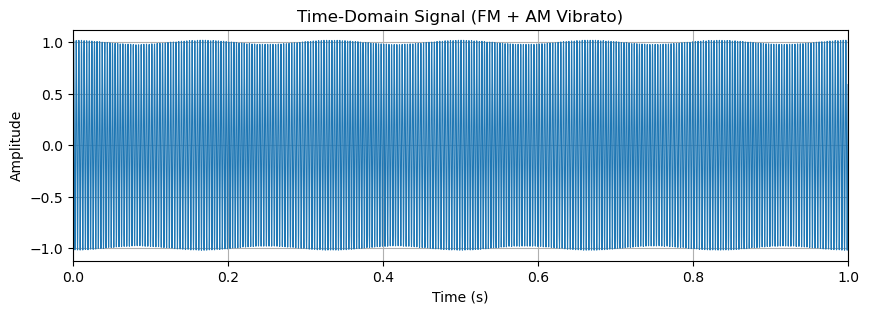

In [338]:
plt.figure(figsize=(10, 3))
plt.plot(t, signal, linewidth=0.8)
plt.title("Time-Domain Signal (FM + AM Vibrato)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0, 1)  # zoom in
plt.grid(True)
plt.show()


In [339]:
def bandpass_filter(signal, fs, f_center, bandwidth=1.0, order=4):
    nyquist = fs / 2
    low = (f_center - bandwidth/2) / nyquist
    high = (f_center + bandwidth/2) / nyquist
    if low <= 0:
        low = 1e-6  # just above 0
    if high >= 1:
        high = 0.999999
    if low >= high:
        raise ValueError(
            f"Invalid bandpass: f_center={f_center}, bandwidth={bandwidth}, fs={fs} "
            f"-> low={low:.3f}, high={high:.3f}"
        )

    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)   

def returnContour(data, samplerate):
    ###CALCULATE vibRate
    sound = Sound(data, samplerate)
    #Creates PRAAT sound file from .wav array, default 44100 Hz sampling frequency?
    # pitch = call(sound, "To Pitch", 0.001, 60, 1000) #Use time steps of 0.001 for 1000 Hz f_s
    pitch = call(sound, "To Pitch", 0.001, 260, 1000) # Raising the low_frequency will reduce the time step and increase resultant fs_contour
    pitch_contour = pitch.selected_array['frequency']

    f_s_contour = pitch.selected_array['frequency'].size/sound.values.size*sound.sampling_frequency
    return pitch_contour, f_s_contour
    

def returnEnvelope(data, samplerate,meanFreq):
        bandwidth_h = meanFreq#2 * f_h * (2**(vib_cents/1200) - 1) * 1.3
        filtered = bandpass_filter(data, samplerate, meanFreq, bandwidth_h)
        env_pa = np.abs(hilbert(filtered))
        return env_pa, filtered, samplerate

In [340]:
pitch_contour, f_s_contour = returnContour(signal, fs)
envelope, filtered, _ = returnEnvelope(signal, fs, f0)

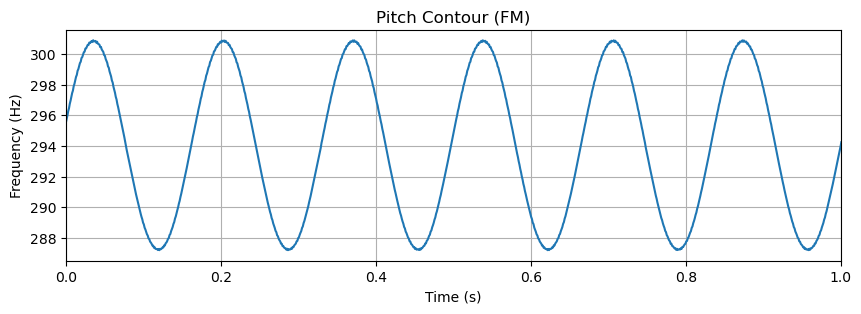

In [341]:
t_pitch = np.arange(len(pitch_contour)) / f_s_contour

plt.figure(figsize=(10, 3))
plt.plot(t_pitch, pitch_contour)
plt.title("Pitch Contour (FM)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.xlim(0,1)
plt.grid(True)
plt.show()


So the pitch contour shows 6 oscillations in one second. So far so good.

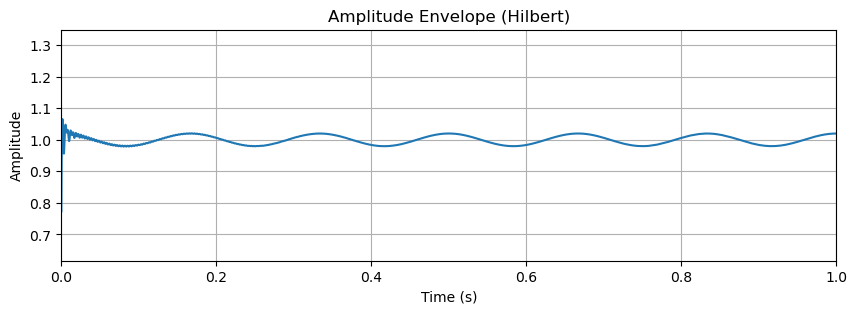

In [342]:
t_env = np.arange(len(envelope)) / fs

plt.figure(figsize=(10, 3))
plt.plot(t_env, envelope)
plt.title("Amplitude Envelope (Hilbert)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0, 1)
plt.grid(True)
plt.show()


The amplitude contour likewise shows 6 oscillations in one second with some noise at the boundary of the signal.

In [343]:
def compute_vibrato_extent_cents(pitch_contour, f_s_contour, vibFreq, windowFactor=0):
    if np.isnan(vibFreq):
        #vibFreq = 5.5
        ampCents = np.nan
        #print(str(ampCents))
        return ampCents
    wavelength = 1.0/vibFreq*f_s_contour # in frames
    # print('wavelength: ', str(wavelength))
    try:
        window = math.floor(wavelength*windowFactor)
    except ValueError:
        window = math.floor(1.0/5.5*f_s_contour*0.75)
    #
    if window == 0:
        window = 1
    # print('Window: ', str(window))
    maxPeaks = find_peaks(pitch_contour, distance=window)[0]
    prominences = scipy.signal.peak_prominences(pitch_contour, maxPeaks)[0]/2

    ampEstimate = prominences[1:-1].mean()
    meanFreq = pitch_contour[1:-1].mean()
    # ampStd = prominences[1:-2].std()
    ampStd = prominences[1:-1].std()
    #
    vibExtent_cents = 1200*np.log(1 + ampEstimate/meanFreq)/np.log(2)
    return vibExtent_cents, maxPeaks, prominences#, vibStd # amplitude in cents

Estimated vibrato extent: 39.8211 (cents)


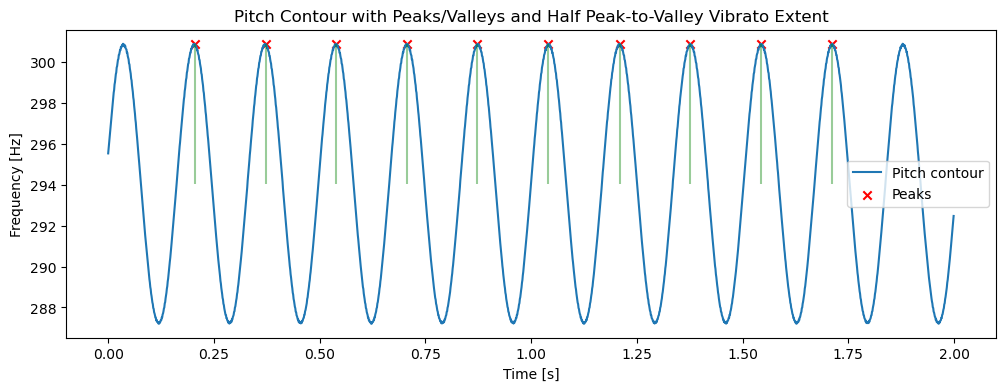

In [344]:
vibExtent_cents, peaks, half_prominences = compute_vibrato_extent_cents(pitch_contour, f_s_contour, vibRate_fm, windowFactor=0.75)
print(f"Estimated vibrato extent: {vibExtent_cents:.4f} (cents)")
# --- Visualization ---
plt.figure(figsize=(12,4))
plt.plot(t_pitch, pitch_contour, label='Pitch contour')
plt.scatter(t_pitch[peaks[1:-1]], pitch_contour[peaks[1:-1]], color='red', marker='x', label='Peaks')
#plt.scatter(t_pitch[valleys], pitch_contour[valleys], color='green', marker='o', label='Valleys')

# Draw half peak-to-valley lines
for p, prom in zip(peaks[1:-1], half_prominences[1:-1]):
    plt.vlines(t_pitch[p], pitch_contour[p]-prom, pitch_contour[p], color='green', alpha=0.4)

plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.title('Pitch Contour with Peaks/Valleys and Half Peak-to-Valley Vibrato Extent')
plt.legend()
plt.show()

In [345]:
# --- Function to estimate vibrato extent (AM) ---
def compute_vibrato_extent_hilbert(envelope, samplerate, vibAmpGuess):
    wavelength = 1.0 / vibAmpGuess * samplerate
    window = int(np.floor(wavelength * 0.75))
    if window <= 0:
        window = 1
    
    maxPeaks = find_peaks(envelope[window:-window], distance=window)[0] 
    prominences = peak_prominences(envelope[window:-window], maxPeaks)[0]
    extentEstimate = np.nanmedian(prominences) / 2
    return extentEstimate, (maxPeaks + window), prominences

Estimated vibrato extent: 0.0201 (percent of mean signal amplitude)


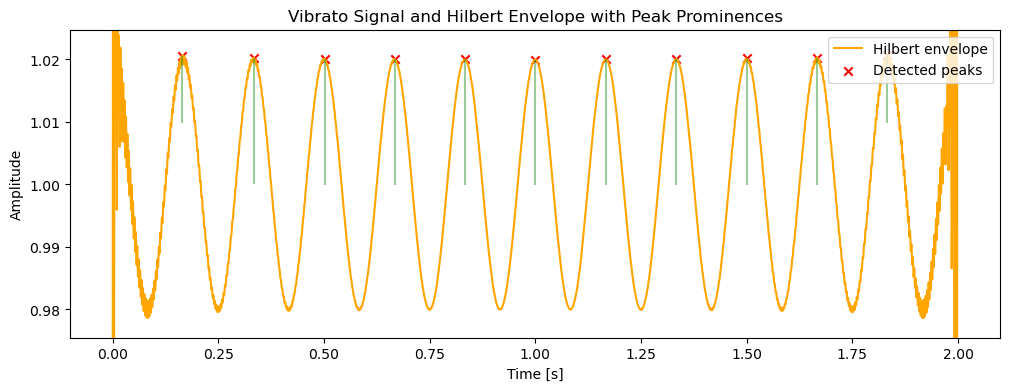

In [346]:
# --- Estimate vibrato extent ---
extentEstimate, peaks, prominences = compute_vibrato_extent_hilbert(envelope, fs, vibRate_am)
half_prominences = prominences / 2
print(f"Estimated vibrato extent: {extentEstimate:.4f} (percent of mean signal amplitude)")

# --- Visualization ---
plt.figure(figsize=(12,4))
# plt.plot(t, signal, label='Vibrato signal')
plt.plot(t, envelope, color='orange', label='Hilbert envelope')
plt.scatter(t[peaks], envelope[peaks], color='red', marker='x', label='Detected peaks')
for p, prom in zip(peaks, half_prominences):
    plt.vlines(t[p], envelope[p]-prom, envelope[p], color='green', alpha=0.4)

yRange = envelope[peaks[1]:peaks[-1]].max()
peak_vals = envelope[peaks[1]:peaks[-1]]
ymin, ymax = peak_vals.min(), peak_vals.max()
yrange = ymax - ymin
plt.ylim(ymin - 0.1*yrange, ymax + 0.1*yrange)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Vibrato Signal and Hilbert Envelope with Peak Prominences')
plt.legend()
plt.show()

In [347]:
def extract_phase_difference(
    envelope,
    pitch_contour,
    fs_env,
    fs_pitch,
    vibRate_f0,
    vibRate_amp,
    rate_tol=0.5  # Hz tolerance
):
    """
    Estimate AM–FM phase difference at the vibrato rate.

    Returns np.nan if vibrato rates do not match within tolerance.
    """

    # --- 1. Reject mismatched rates ---
    if np.isnan(vibRate_f0) or np.isnan(vibRate_amp):
        return np.nan

    if abs(vibRate_f0 - vibRate_amp) > rate_tol:
        return np.nan

    vibRate = 0.5 * (vibRate_f0 + vibRate_amp)

    # --- 2. Resample signals to common length ---
    N = min(len(envelope), len(pitch_contour))
    envelope_rs = resample(envelope, N)
    pitch_rs = resample(pitch_contour, N)

    fs = min(fs_env, fs_pitch)
    t = np.arange(N) / fs

    # --- 3. Remove DC ---
    env = envelope_rs - np.mean(envelope_rs)
    pitch = pitch_rs - np.mean(pitch_rs)

    # --- 4. Reference sinusoids ---
    omega = 2 * np.pi * vibRate
    sin_ref = np.sin(omega * t)
    cos_ref = np.cos(omega * t)

    # --- 5. Phase via projection ---
    def estimate_phase(x):
        a = np.dot(x, cos_ref)
        b = np.dot(x, sin_ref)
        return np.arctan2(b, a)

    phi_env = estimate_phase(env)
    phi_pitch = estimate_phase(pitch)

    # --- 6. Phase difference ---
    phase_diff = phi_env - phi_pitch
    phase_diff = np.arctan2(np.sin(phase_diff), np.cos(phase_diff))

    return phase_diff

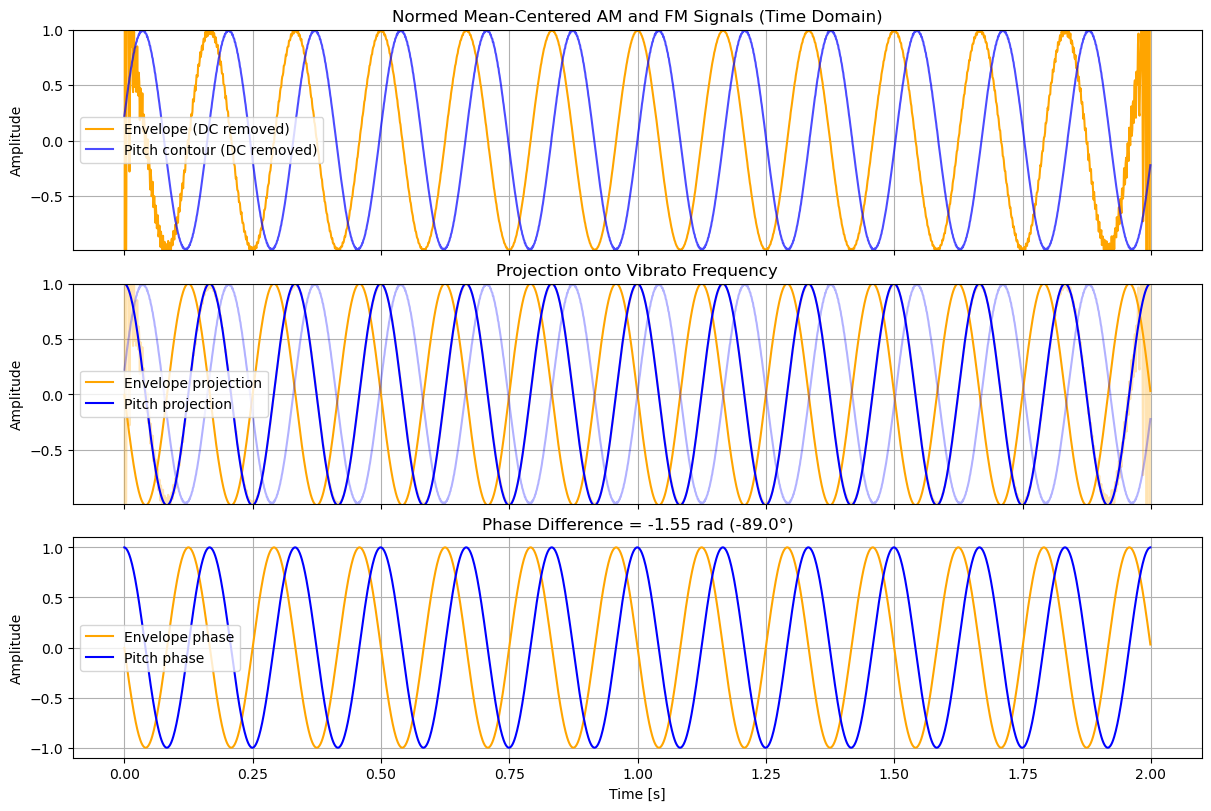

In [351]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import resample

def visualize_phase_difference(
    envelope,
    pitch_contour,
    fs_env,
    fs_pitch,
    vibRate_f0,
    vibRate_amp,
    rate_tol=0.5
):
    phase_diff = extract_phase_difference(
        envelope,
        pitch_contour,
        fs_env,
        fs_pitch,
        vibRate_f0,
        vibRate_amp,
        rate_tol
    )
    
    if np.isnan(phase_diff):
        print("Phase difference could not be estimated (rate mismatch or NaN).")
        return np.nan

    vibRate = 0.5 * (vibRate_f0 + vibRate_amp)

    # --- Resample ---
    N = min(len(envelope), len(pitch_contour))
    env_rs = resample(envelope, N)
    pitch_rs = resample(pitch_contour, N)

    fs = min(fs_env, fs_pitch)
    t = np.arange(N) / fs

    # --- Remove DC and Min-Max Norm---
    env = env_rs - np.mean(env_rs)
    sampleMax = np.abs(env[(len(env)//4):(len(env)*3 // 4)]).max()
    env = env / sampleMax 
    pitch = pitch_rs - np.mean(pitch_rs) 
    pitch = pitch / np.abs(pitch).max()

    # --- Reference ---
    omega = 2 * np.pi * vibRate
    sin_ref = np.sin(omega * t)
    cos_ref = np.cos(omega * t)

    # --- Phase estimation (same as original) ---
    def estimate_phase(x):
        a = np.dot(x, sin_ref)
        b = np.dot(x, cos_ref)
        return np.arctan2(b, a)

    phi_env = estimate_phase(env)
    phi_pitch = estimate_phase(pitch)

    # --- Reconstructed sinusoids ---
    env_hat = np.cos(omega * t + phi_env)
    pitch_hat = np.cos(omega * t + phi_pitch)

    # --- Visualization ---
    fig, axs = plt.subplots(
        3, 1,
        figsize=(12, 8),
        sharex=True,
        constrained_layout=True
    )

    # 1. Original signals
    axs[0].plot(t, env, label='Envelope (DC removed)', color='orange')
    axs[0].plot(t, pitch, label='Pitch contour (DC removed)', color='blue', alpha=0.7)
    axs[0].set_title('Normed Mean-Centered AM and FM Signals (Time Domain)')
    axs[0].set_ylabel('Amplitude')
    axs[0].set_ylim(pitch.min(), pitch.max())
    axs[0].legend()
    axs[0].grid(True)

    # 2. Projection onto vibrato sinusoid
    axs[1].plot(t, env, color='orange', alpha=0.3)
    axs[1].plot(t, env_hat, color='orange', label='Envelope projection')
    axs[1].plot(t, pitch, color='blue', alpha=0.3)
    axs[1].plot(t, pitch_hat, color='blue', label='Pitch projection')
    axs[1].set_title('Projection onto Vibrato Frequency')
    axs[1].set_ylabel('Amplitude')
    axs[1].set_ylim(pitch.min(), pitch.max())
    axs[1].legend()
    axs[1].grid(True)

    # 3. Phase difference visualization
    axs[2].plot(t, env_hat, color='orange', label='Envelope phase')
    axs[2].plot(t, pitch_hat, color='blue', label='Pitch phase')
    axs[2].set_title(
        f'Phase Difference = {phase_diff:.2f} rad '
        f'({np.degrees(phase_diff):.1f}°)'
    )
    axs[2].set_xlabel('Time [s]')
    axs[2].set_ylabel('Amplitude')
    axs[2].legend()
    axs[2].grid(True)

    plt.show()

    return phase_diff
phase_diff = visualize_phase_difference(
    envelope,
    pitch_contour,
    fs_env=f_s,
    fs_pitch=f_s_contour,
    vibRate_f0=vibRate_fm,
    vibRate_amp=vibRate_am
)


So that makes intuitive sense. The amplitude envelope projections perfectly align because we modeled instantaneous amplitude as cosine. The pitch projection is $\pi / 2$ displaced because we modeled it as sine. 
The two signals are $\pi / 2$ phase shifted as neither was phase shifted and one was cosine and the other sine.

What are the results with a synthesized vocal signal?

In [352]:
import soundfile as sf
filename = "294_6_40_6_2.wav"
signal, f_s = sf.read(filename)
t = np.arange(0, len(signal))/f_s
f0, vibRateFM_gt, vibExtentFM_gt, Flutter_f0, FlutterDepth = filename.split('.')[0].split('_')
FlutterDepthPerc = float(FlutterDepth) / 100

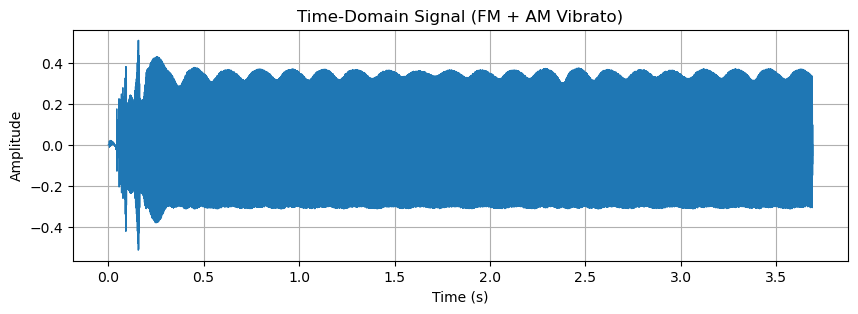

In [353]:
plt.figure(figsize=(10, 3))
plt.plot(t, signal, linewidth=0.8)
plt.title("Time-Domain Signal (FM + AM Vibrato)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
# plt.xlim(0, 1)  # zoom in
plt.grid(True)
plt.show()

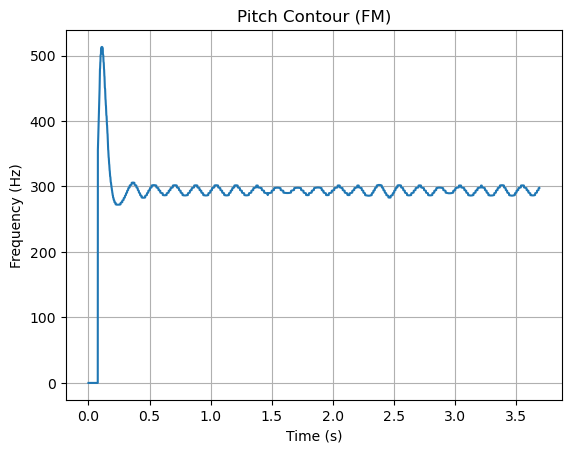

In [354]:
pitch_contour, f_s_contour = returnContour(signal, f_s)
t_pitch = np.arange(len(pitch_contour)) / f_s_contour
plt.plot(t_pitch, pitch_contour)
plt.title("Pitch Contour (FM)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
# plt.xlim(0,4)
plt.grid(True)
plt.show()

So we have some onset behavior for the synthesized sustained tone. Let's look at the middle 50% of the contour.

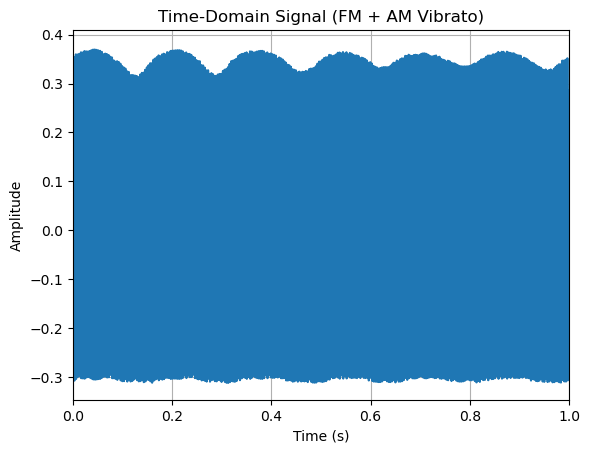

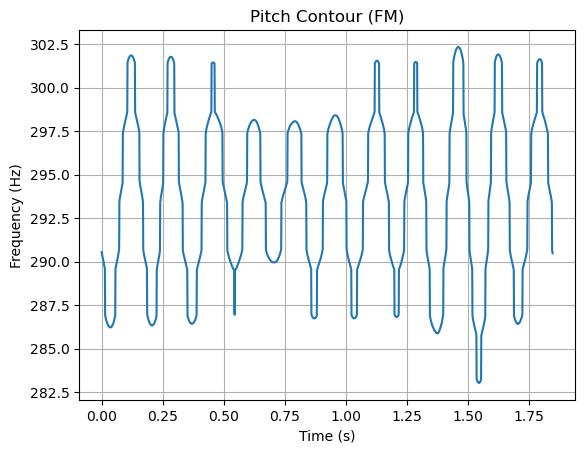

In [355]:
begin50 = round(len(signal)*.25)
end50 = round(len(signal)*.75)
signal50 = signal[begin50:end50]
t50 = np.arange(0, len(signal50))/f_s
plt.figure()
plt.plot(t50, signal50)
plt.title("Time-Domain Signal (FM + AM Vibrato)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.xlim(0, 1)  # zoom in
plt.grid(True)
plt.show()
pitch_contour, f_s_contour = returnContour(signal[begin50:end50], f_s)
t_pitch = np.arange(len(pitch_contour)) / f_s_contour
plt.figure()
plt.plot(t_pitch, pitch_contour)
plt.title("Pitch Contour (FM)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
# plt.xlim(0,4)
plt.grid(True)
plt.show()

In [356]:
def autocorrVib3HzLocal(pitch_contour, f_s_contour):
    x = pitch_contour
    n = len(x)
    acorr = sm.tsa.acf(x, nlags=n-1)
    
    # 95% Confidence interval
    highCI = 1.96 / math.sqrt(n)
    lowCI = -highCI

    # Desired frequency range: 3–10 Hz
    frame10Hz = math.floor(f_s_contour / 10)
    frame3Hz = math.floor(f_s_contour / 3)

    # Find local maxima in desired range
    acorr_segment = acorr[frame10Hz:frame3Hz]
    peaks, _ = find_peaks(acorr_segment)

    vibratoFreq = np.nan
    if len(peaks) > 0:
        # Get correlation values for each peak
        peak_values = acorr_segment[peaks]
        
        # Filter only those above the confidence interval
        valid_indices = np.where(peak_values > highCI)[0]
        
        if len(valid_indices) > 0:
            # Find the *highest* local maximum
            best_peak_idx = valid_indices[np.argmax(peak_values[valid_indices])]
            maxLag = peaks[best_peak_idx] + frame10Hz
            vibratoFreq = f_s_contour / maxLag
        # else: vibratoFreq remains np.nan

    return vibratoFreq

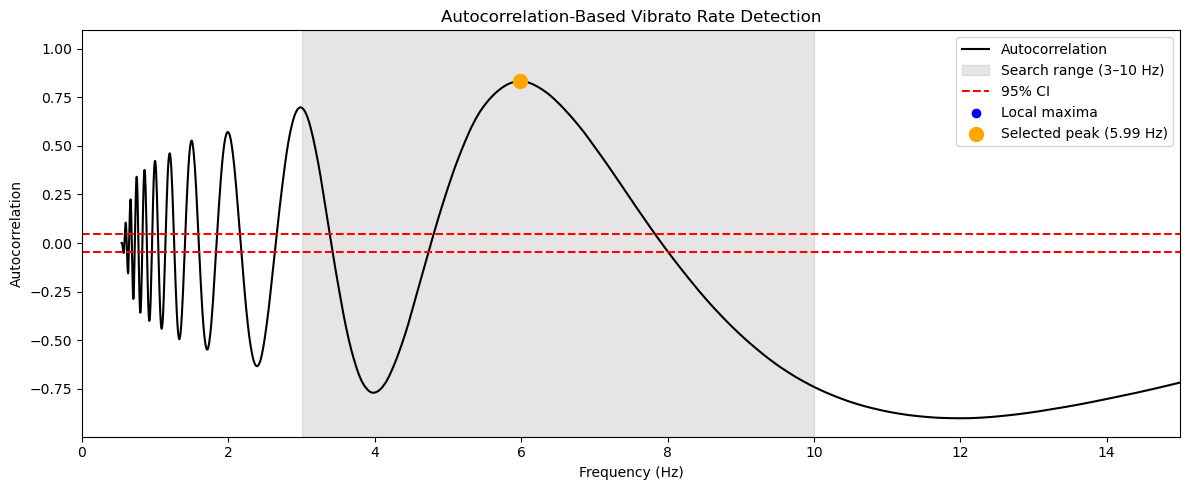

Estimated vibrato rate: 5.99 Hz


In [357]:
def visualize_autocorrVib3HzLocal(pitch_contour, f_s_contour):
    x = pitch_contour
    n = len(x)

    # --- Autocorrelation ---
    acorr = sm.tsa.acf(x, nlags=n-1)

    # 95% confidence interval
    highCI = 1.96 / math.sqrt(n)
    lowCI = -highCI

    # Frequency → lag conversion
    frame10Hz = math.floor(f_s_contour / 10)
    frame3Hz = math.floor(f_s_contour / 3)

    # Segment of interest
    acorr_segment = acorr[frame10Hz:frame3Hz]
    peaks, _ = find_peaks(acorr_segment)

    vibratoFreq = np.nan
    best_lag = None

    if len(peaks) > 0:
        peak_values = acorr_segment[peaks]
        valid_indices = np.where(peak_values > highCI)[0]

        if len(valid_indices) > 0:
            best_peak_idx = valid_indices[np.argmax(peak_values[valid_indices])]
            best_lag = peaks[best_peak_idx] + frame10Hz
            vibratoFreq = f_s_contour / best_lag

    # --- Visualization ---
    lags = np.arange(len(acorr))
    freqs = f_s_contour / np.maximum(lags, 1)  # avoid div-by-zero

    plt.figure(figsize=(12, 5))
    plt.plot(freqs, acorr, label='Autocorrelation', color='black')

    # Highlight search band
    plt.axvspan(3, 10, color='gray', alpha=0.2, label='Search range (3–10 Hz)')

    # Confidence interval
    plt.axhline(highCI, color='red', linestyle='--', label='95% CI')
    plt.axhline(lowCI, color='red', linestyle='--')

    # Plot peaks
    if len(peaks) > 0:
        peak_lags = peaks + frame10Hz
        peak_freqs = f_s_contour / peak_lags
        plt.scatter(
            peak_freqs,
            acorr[peak_lags],
            color='blue',
            label='Local maxima'
        )

    # Highlight chosen peak
    if best_lag is not None:
        best_freq = f_s_contour / best_lag
        plt.scatter(
            best_freq,
            acorr[best_lag],
            color='orange',
            s=100,
            zorder=5,
            label=f'Selected peak ({best_freq:.2f} Hz)'
        )

    plt.xlim(0, 15)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Autocorrelation')
    plt.title('Autocorrelation-Based Vibrato Rate Detection')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return vibratoFreq
vib_rate_est = visualize_autocorrVib3HzLocal(pitch_contour, f_s_contour)
print(f"Estimated vibrato rate: {vib_rate_est:.2f} Hz")

Estimated vibrato extent: 39.8193 (cents)


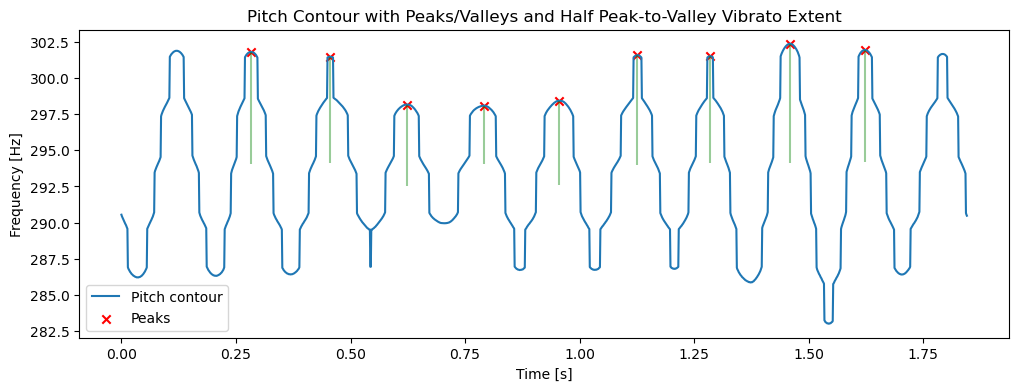

In [358]:
vibExtent_cents, peaks, half_prominences = compute_vibrato_extent_cents(pitch_contour, f_s_contour, vibRate_fm, windowFactor=0.75)
print(f"Estimated vibrato extent: {vibExtent_cents:.4f} (cents)")
# --- Visualization ---
plt.figure(figsize=(12,4))
plt.plot(t_pitch, pitch_contour, label='Pitch contour')
plt.scatter(t_pitch[peaks[1:-1]], pitch_contour[peaks[1:-1]], color='red', marker='x', label='Peaks')
#plt.scatter(t_pitch[valleys], pitch_contour[valleys], color='green', marker='o', label='Valleys')

# Draw half peak-to-valley lines
for p, prom in zip(peaks[1:-1], half_prominences[1:-1]):
    plt.vlines(t_pitch[p], pitch_contour[p]-prom, pitch_contour[p], color='green', alpha=0.4)

plt.xlabel('Time [s]')
plt.ylabel('Frequency [Hz]')
plt.title('Pitch Contour with Peaks/Valleys and Half Peak-to-Valley Vibrato Extent')
plt.legend()
plt.show()

Now that we have a synthetic signal we have more than one harmonic to analyze. Let's look at the amplitude envelope of the first and second harmonic:

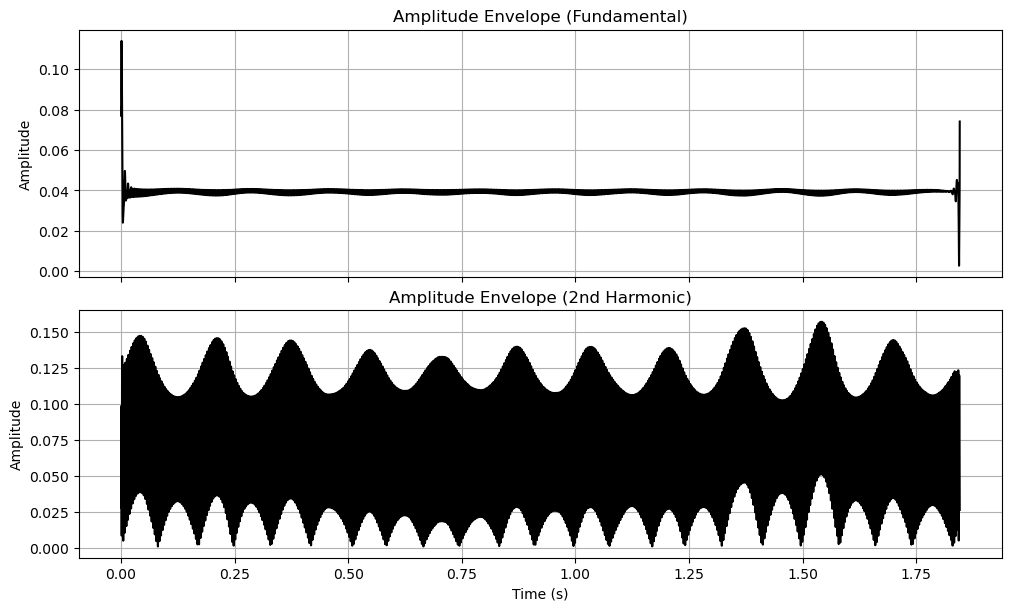

In [359]:
# Filter around the fundamental and calculate hilbert envelope
meanFreq = np.mean(pitch_contour)

# --- Compute envelopes ---
envelope1, filtered1, f_s = returnEnvelope(signal50, f_s, meanFreq)
envelope2, filtered2, f_s = returnEnvelope(signal50, f_s, 2 * meanFreq)

# --- Plot ---
fig, axs = plt.subplots(
    2, 1,
    figsize=(10, 6),
    sharex=True,
    constrained_layout=True
)

# Fundamental envelope
axs[0].plot(t50, envelope1, color='black')
axs[0].set_title('Amplitude Envelope (Fundamental)')
axs[0].set_ylabel('Amplitude')
axs[0].grid(True)

# 2nd harmonic envelope
axs[1].plot(t50, envelope2, color='black')
axs[1].set_title('Amplitude Envelope (2nd Harmonic)')
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('Amplitude')
axs[1].grid(True)

# Optional: zoom in time
# axs[0].set_xlim(0.5, 1.5)

plt.show()


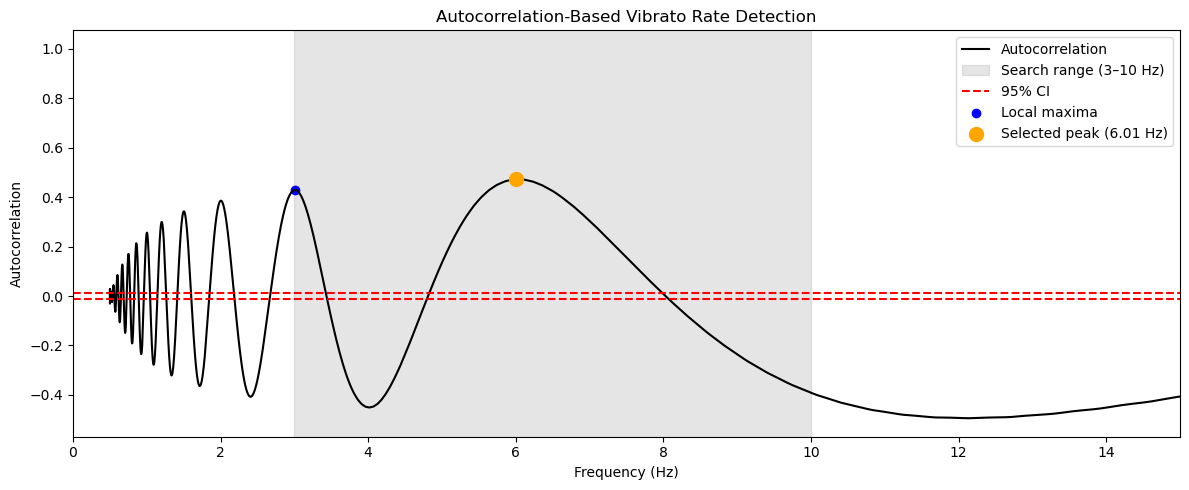

Estimated vibrato rate: 6.01 Hz


In [360]:
def visualize_autocorrVib3HzLocal(pitch_contour, f_s_contour):
    x = pitch_contour
    n = len(x)

    # --- Autocorrelation ---
    acorr = sm.tsa.acf(x, nlags=n-1)

    # 95% confidence interval
    highCI = 1.96 / math.sqrt(n)
    lowCI = -highCI

    # Frequency → lag conversion
    frame10Hz = math.floor(f_s_contour / 10)
    frame3Hz = math.floor(f_s_contour / 3)

    # Segment of interest
    acorr_segment = acorr[frame10Hz:frame3Hz]
    peaks, _ = find_peaks(acorr_segment)

    vibratoFreq = np.nan
    best_lag = None

    if len(peaks) > 0:
        peak_values = acorr_segment[peaks]
        valid_indices = np.where(peak_values > highCI)[0]

        if len(valid_indices) > 0:
            best_peak_idx = valid_indices[np.argmax(peak_values[valid_indices])]
            best_lag = peaks[best_peak_idx] + frame10Hz
            vibratoFreq = f_s_contour / best_lag

    # --- Visualization ---
    lags = np.arange(len(acorr))
    freqs = f_s_contour / np.maximum(lags, 1)  # avoid div-by-zero

    plt.figure(figsize=(12, 5))
    plt.plot(freqs, acorr, label='Autocorrelation', color='black')

    # Highlight search band
    plt.axvspan(3, 10, color='gray', alpha=0.2, label='Search range (3–10 Hz)')

    # Confidence interval
    plt.axhline(highCI, color='red', linestyle='--', label='95% CI')
    plt.axhline(lowCI, color='red', linestyle='--')

    # Plot peaks
    if len(peaks) > 0:
        peak_lags = peaks + frame10Hz
        peak_freqs = f_s_contour / peak_lags
        plt.scatter(
            peak_freqs,
            acorr[peak_lags],
            color='blue',
            label='Local maxima'
        )

    # Highlight chosen peak
    if best_lag is not None:
        best_freq = f_s_contour / best_lag
        plt.scatter(
            best_freq,
            acorr[best_lag],
            color='orange',
            s=100,
            zorder=5,
            label=f'Selected peak ({best_freq:.2f} Hz)'
        )

    plt.xlim(0, 15)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Autocorrelation')
    plt.title('Autocorrelation-Based Vibrato Rate Detection')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return vibratoFreq
vib_rate_est = visualize_autocorrVib3HzLocal(envelope, fs)
print(f"Estimated vibrato rate: {vib_rate_est:.2f} Hz")

There is some harmonic behavior happening in the envelope

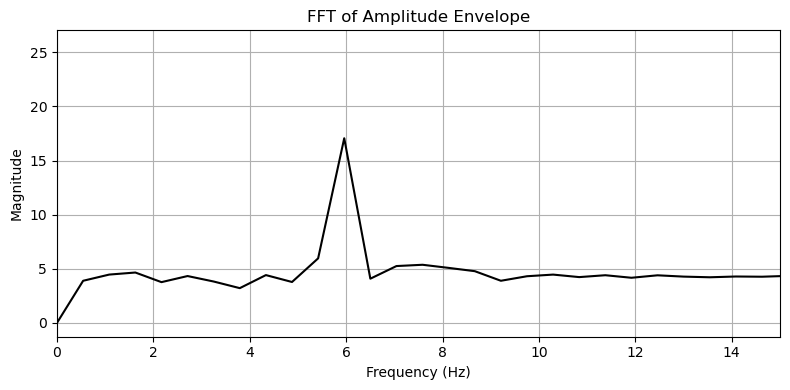

Dominant Vibrato Frequency (AM): 5.96 HZ


In [367]:
def visualize_envelope_fft(envelope, fs, max_freq=20, Type=""):
    """
    Visualize FFT of an envelope.

    Parameters
    ----------
    envelope : np.ndarray
        Amplitude envelope (e.g., abs(hilbert(signal)))
    fs : float
        Sampling rate of the envelope (Hz)
    max_freq : float
        Maximum frequency to display (Hz)
    """

    # Remove DC offset (VERY important for envelope FFT)
    env = envelope - np.mean(envelope)

    # FFT
    N = len(env)
    fft_vals = np.fft.rfft(env)
    freqs = np.fft.rfftfreq(N, d=1/fs)

    magnitude = np.abs(fft_vals)

    # Plot
    plt.figure(figsize=(8, 4))
    plt.plot(freqs, magnitude, color='black')
    band_mask = (freqs >= 3) & (freqs <= 10)

    if not np.any(band_mask):
        return np.nan

    band_mag = magnitude[band_mask]
    band_freqs = freqs[band_mask]

    # Peak frequency
    peak_freq = band_freqs[np.argmax(band_mag)]

    plt.xlim(0, max_freq)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.title(f'FFT of {Type}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    
    return peak_freq
peakFreq_am = visualize_envelope_fft(envelope1, f_s, max_freq=15, Type="Amplitude Envelope")
print(f"Dominant Vibrato Frequency (AM): {peakFreq_am:.2f} HZ")

That's much cleaner. 
It works with the pitch contour as well:

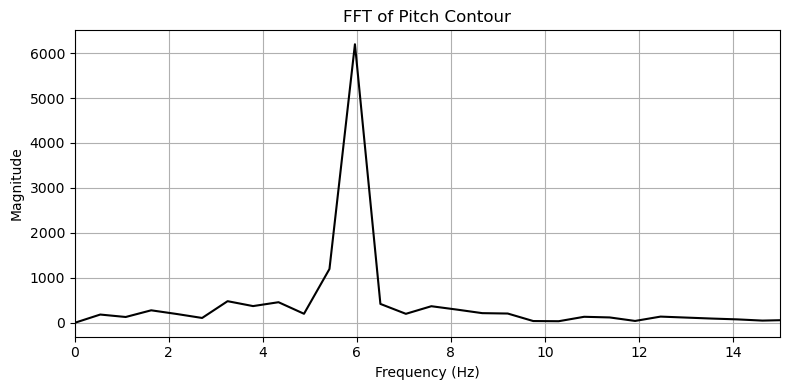

Dominant Vibrato Frequency (FM): 5.96 HZ


In [368]:
peakFreq_fm = visualize_envelope_fft(pitch_contour, f_s_contour, max_freq=15, Type="Pitch Contour")
print(f"Dominant Vibrato Frequency (FM): {peakFreq_fm:.2f} HZ")

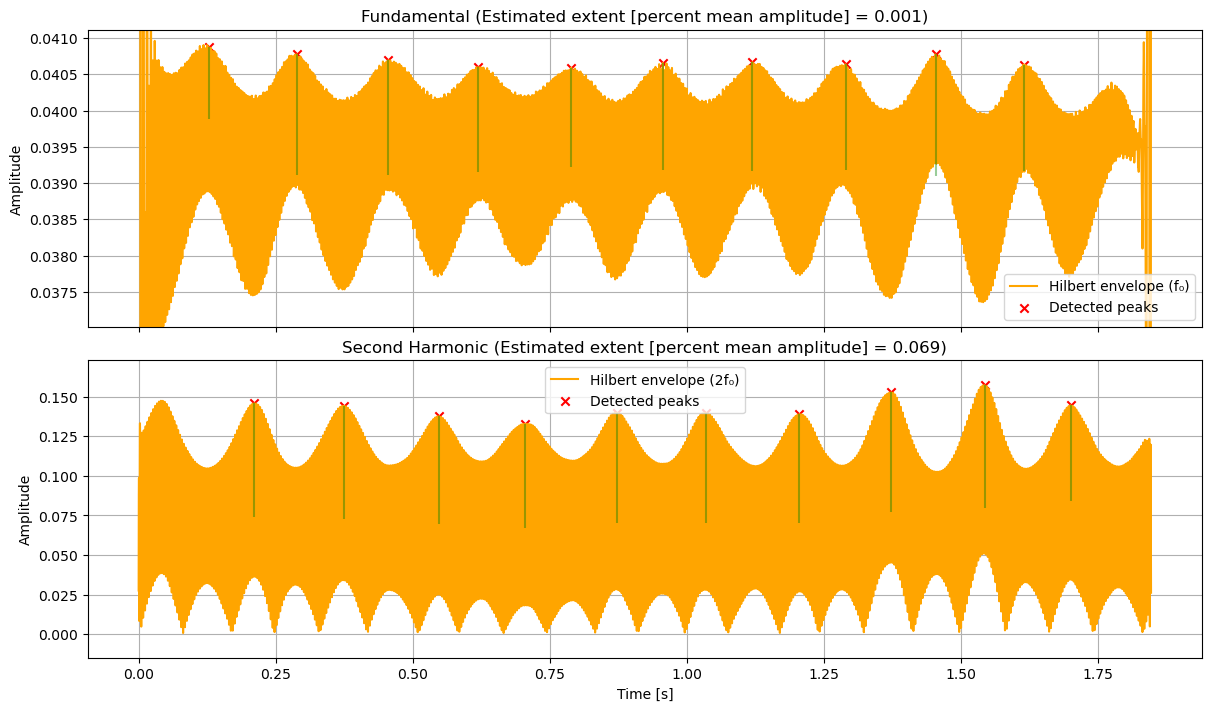

In [369]:
fig,axs = plt.subplots(
    2, 1,
    figsize=(12, 7),
    sharex=True,
    constrained_layout=True
)

# -------------------------
# Fundamental (envelope1)
# -------------------------
extent_f0, peaks_f0, prominences_f0 = compute_vibrato_extent_hilbert(
    envelope1, f_s, peakFreq
)
half_prom_f0 = prominences_f0 / 2

axs[0].plot(t50, envelope1, color='orange', label='Hilbert envelope (f₀)')
axs[0].scatter(
    t50[peaks_f0], envelope1[peaks_f0],
    color='red', marker='x', label='Detected peaks'
)

for p, prom in zip(peaks_f0, half_prom_f0):
    axs[0].vlines(
        t50[p],
        envelope1[p] - prom,
        envelope1[p],
        color='green',
        alpha=0.4
    )

vals = envelope1[peaks_f0[1]:peaks_f0[-1]]
ymin, ymax = vals.min(), vals.max()
yrange = ymax - ymin
axs[0].set_ylim(ymin - 0.1 * yrange, ymax + 0.1 * yrange)

axs[0].set_title(
    f'Fundamental (Estimated extent [percent mean amplitude] = {extent_f0:.3f})'
)
axs[0].set_ylabel('Amplitude')
axs[0].legend()
axs[0].grid(True)

# -------------------------
# Second harmonic (envelope2)
# -------------------------
extent_2f0, peaks_2f0, prominences_2f0 = compute_vibrato_extent_hilbert(
    envelope2, f_s, peakFreq
)
half_prom_2f0 = prominences_2f0 / 2

axs[1].plot(t50, envelope2, color='orange', label='Hilbert envelope (2f₀)')
axs[1].scatter(
    t50[peaks_2f0], envelope2[peaks_2f0],
    color='red', marker='x', label='Detected peaks'
)

for p, prom in zip(peaks_2f0, half_prom_2f0):
    axs[1].vlines(
        t50[p],
        envelope2[p] - prom,
        envelope2[p],
        color='green',
        alpha=0.4
    )

vals = envelope2[peaks_2f0[1]:peaks_2f0[-1]]
ymin, ymax = vals.min(), vals.max()
yrange = ymax - ymin
axs[1].set_ylim(ymin - 0.1 * yrange, ymax + 0.1 * yrange)

axs[1].set_title(
    f'Second Harmonic (Estimated extent [percent mean amplitude] = {extent_2f0:.3f})'
)
axs[1].set_xlabel('Time [s]')
axs[1].set_ylabel('Amplitude')
axs[1].legend()
axs[1].grid(True)

plt.show()


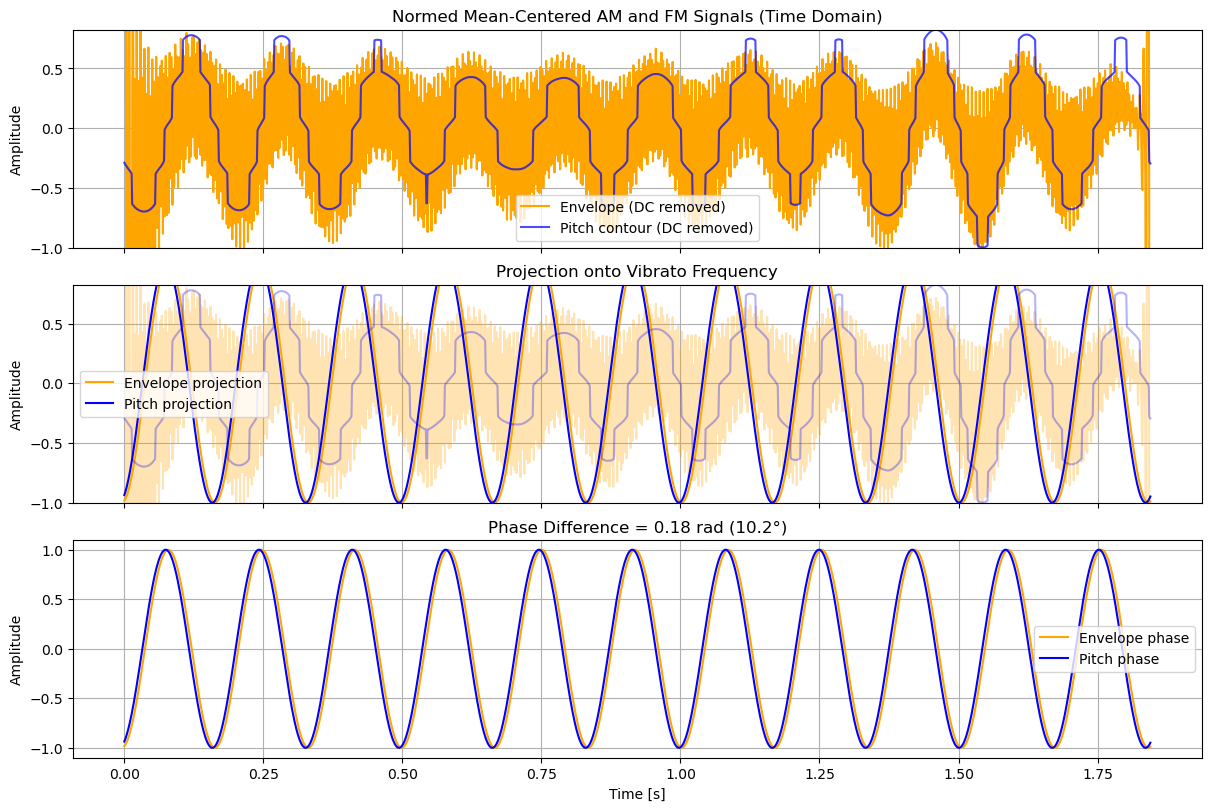

In [370]:
phase_diff = visualize_phase_difference(
    envelope1,
    pitch_contour,
    fs_env=f_s,
    fs_pitch=f_s_contour,
    vibRate_f0=peakFreq_fm,
    vibRate_amp=peakFreq_am
)

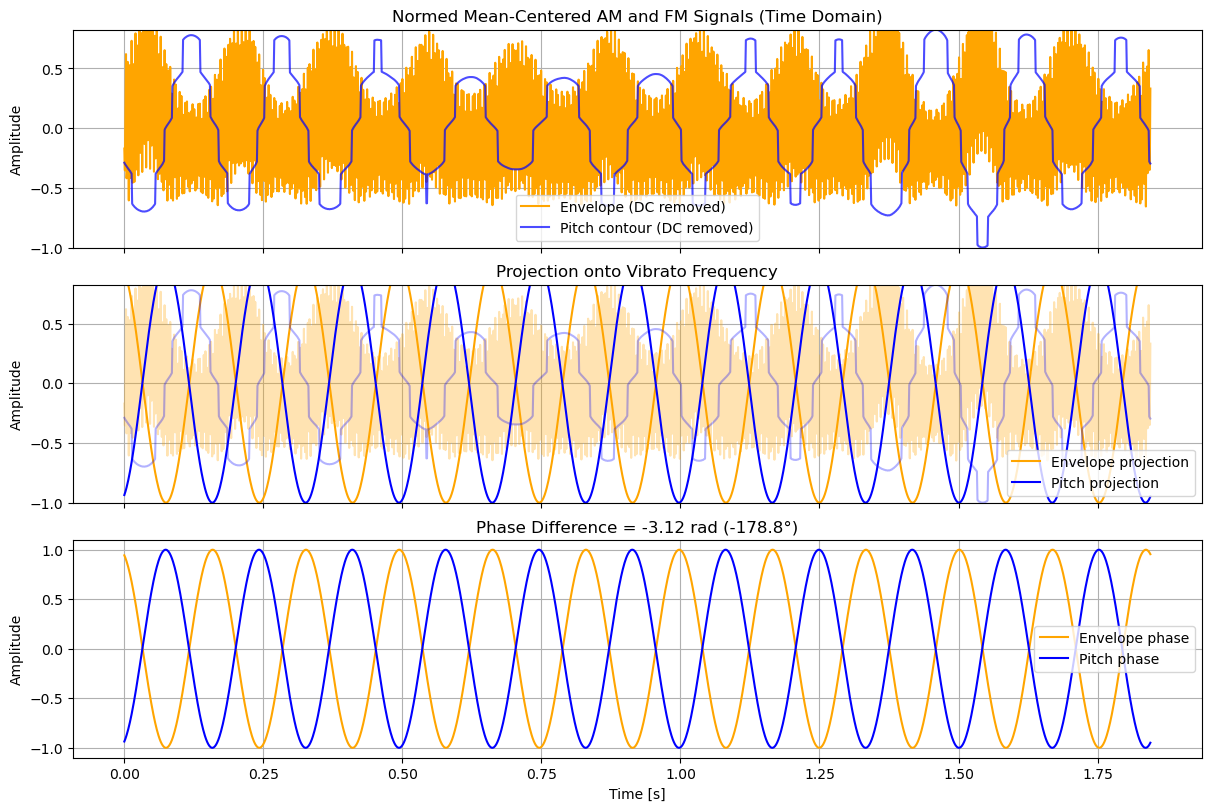

In [371]:
phase_diff = visualize_phase_difference(
    envelope2,
    pitch_contour,
    fs_env=f_s,
    fs_pitch=f_s_contour,
    vibRate_f0=peakFreq_fm,
    vibRate_amp=peakFreq_am
)

What!? That's wild. So envelope1 and envelope2 are $\pi /2$ phase delayed?

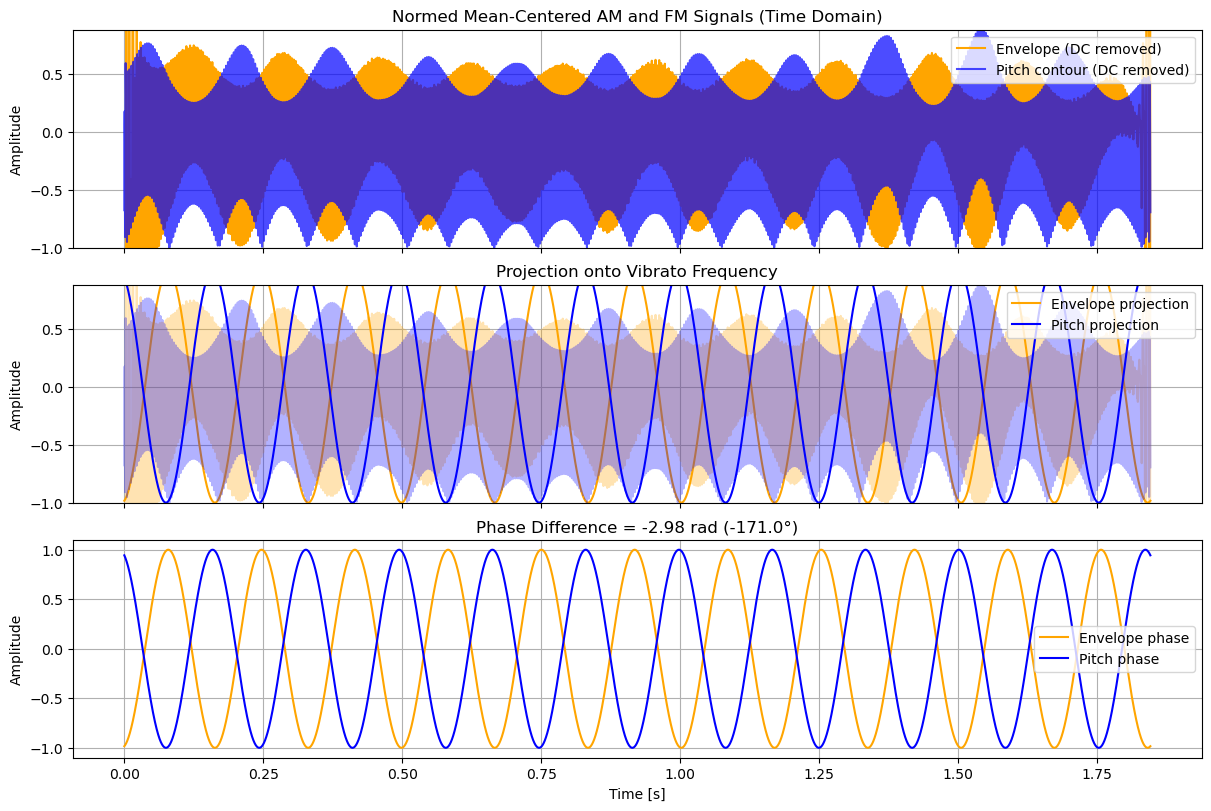

In [372]:
phase_diff = visualize_phase_difference(
    envelope1,
    envelope2,
    fs_env=f_s,
    fs_pitch=f_s,
    vibRate_f0=peakFreq_am,
    vibRate_amp=peakFreq_am
)